In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# %cd /content/drive/MyDrive/NER

In [3]:
# !pip install transformers seqeval[gpu]

## **Fine-tuning BERT for named-entity recognition**

In this notebook, we are going to use **BertForTokenClassification** which is included in the [Transformers library](https://github.com/huggingface/transformers) by HuggingFace. This model has BERT as its base architecture, with a token classification head on top, allowing it to make predictions at the token level, rather than the sequence level. Named entity recognition is typically treated as a token classification problem, so that's what we are going to use it for.

This tutorial uses the idea of **transfer learning**, i.e. first pretraining a large neural network in an unsupervised way, and then fine-tuning that neural network on a task of interest. In this case, BERT is a neural network pretrained on 2 tasks: masked language modeling and next sentence prediction. Now, we are going to fine-tune this network on a NER dataset. Fine-tuning is supervised learning, so this means we will need a labeled dataset.

If you want to know more about BERT, I suggest the following resources:
* the original [paper](https://arxiv.org/abs/1810.04805)
* Jay Allamar's [blog post](http://jalammar.github.io/illustrated-bert/) as well as his [tutorial](http://jalammar.github.io/a-visual-guide-to-using-bert-for-the-first-time/)
* Chris Mccormick's [Youtube channel](https://www.youtube.com/channel/UCoRX98PLOsaN8PtekB9kWrw)
* Abbishek Kumar Mishra's [Youtube channel](https://www.youtube.com/user/abhisheksvnit)

The following notebook largely follows the same structure as the tutorials by Abhishek Kumar Mishra. For his tutorials on the Transformers library, see his [Github repository](https://github.com/abhimishra91/transformers-tutorials).

NOTE: this notebook assumes basic knowledge about deep learning, BERT, and native PyTorch. If you want to learn more Python, deep learning and PyTorch, I highly recommend cs231n by Stanford University and the FastAI course by Jeremy Howard et al. Both are freely available on the web.  

Now, let's move on to the real stuff!

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertConfig, BertForTokenClassification

/opt/anaconda3/envs/p11/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/envs/p11/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <3FBC4DD9-431F-30F9-B747-F26A414408A9> /opt/anaconda3/envs/p11/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <25C510F7-7AEE-3D64-80ED-95874DC6BECD> /opt/anaconda3/envs/p11/lib/python3.11/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


As deep learning can be accellerated a lot using a GPU instead of a CPU, make sure you can run this notebook in a GPU runtime (which Google Colab provides for free! - check "Runtime" - "Change runtime type" - and set the hardware accelerator to "GPU").

We can set the default device to GPU using the following code (if it prints "cuda", it means the GPU has been recognized):

In [5]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'
print(device)

cpu


#### **Downloading and preprocessing the data**
Named entity recognition (NER) uses a specific annotation scheme, which is defined (at least for European languages) at the *word* level. An annotation scheme that is widely used is called **[IOB-tagging](https://en.wikipedia.org/wiki/Inside%E2%80%93outside%E2%80%93beginning_(tagging)**, which stands for Inside-Outside-Beginning. Each tag indicates whether the corresponding word is *inside*, *outside* or at the *beginning* of a specific named entity. The reason this is used is because named entities usually comprise more than 1 word.

Let's have a look at an example. If you have a sentence like "Barack Obama was born in Hawaï", then the corresponding tags would be   [B-PERS, I-PERS, O, O, O, B-GEO]. B-PERS means that the word "Barack" is the beginning of a person, I-PERS means that the word "Obama" is inside a person, "O" means that the word "was" is outside a named entity, and so on. So one typically has as many tags as there are words in a sentence.

So if you want to train a deep learning model for NER, it requires that you have your data in this IOB format (or similar formats such as [BILOU](https://stackoverflow.com/questions/17116446/what-do-the-bilou-tags-mean-in-named-entity-recognition)). There exist many annotation tools which let you create these kind of annotations automatically (such as Spacy's [Prodigy](https://prodi.gy/), [Tagtog](https://docs.tagtog.net/) or [Doccano](https://github.com/doccano/doccano)). You can also use Spacy's [biluo_tags_from_offsets](https://spacy.io/api/goldparse#biluo_tags_from_offsets) function to convert annotations at the character level to IOB format.

Here, we will use a NER dataset from [Kaggle](https://www.kaggle.com/namanj27/ner-dataset) that is already in IOB format. One has to go to this web page, download the dataset, unzip it, and upload the csv file to this notebook. Let's print out the first few rows of this csv file:

In [6]:
DRIVE = False # change if running on Google Colab

if DRIVE:
    train_data = pd.read_csv('/content/drive/MyDrive/NER/train_ner_doctored.csv')
    eval_data = pd.read_csv('/content/drive/MyDrive/NER/eval_ner_doctored.csv')
    test_data = pd.read_csv('/content/drive/MyDrive/NER/test_ner_doctored.csv')
else:
    # train_data = pd.read_csv('dataset_formation/data/train_ner_doctored.csv')
    # eval_data = pd.read_csv('dataset_formation/data/eval_ner_doctored.csv')
    # test_data = pd.read_csv('dataset_formation/data/test_ner_doctored.csv')
    
    # new data
    train_data = pd.read_csv('dataset_formation/final/train_original_data_v1.0.csv')
    eval_data = pd.read_csv('dataset_formation/final/eval.csv')
    test_data = pd.read_csv('dataset_formation/final/test.csv')

In [7]:
train_data.head(200)

,Unnamed: 0,sentence,term,page_number,file_name,word,tag,word_labels
0,50016,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,NaN,Divabn_Prak10,գիմք,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN..."
1,50017,նախորդ հրատարակիչը վիմագրի ծանոթագրության մեջ ...,Վիմագիր,NaN,Divabn_Prak10,նախորդ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
2,50018,ոմն առյուծի հայր սխիթար ճոն հիշատակված է նաև ա...,վիմագրերից,NaN,Divabn_Prak10,ոմն,O,"O,O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O..."
3,50019,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները,NaN,Divabn_Prak10,պրակն,O,"O,O,O,O,O,B-INSC,I-INSC"
4,50020,արևելյան նիրակի ներկայիս հ շիրակի մարզ վիմագիր...,վիմագիր,NaN,Divabn_Prak10,արևելյան,O,"O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O,O..."
...,...,...,...,...,...,...,...,...
195,50211,մխիթարյանց տեղագրութիւն աբել արքեպիսկոպոս սխիթ...,NaN,NaN,Divabn_Prak10,մխիթարյանց,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O"
196,50212,մխիթարյանց հառիճ աբել արքեպիսկոպոս մխիթարյանց ...,NaN,NaN,Divabn_Prak10,մխիթարյանց,O,"O,O,O,O,O,O,O,O,O"
197,50213,գ նալբանդյան հուշարձան գ գ նալբանդյան արթիկի փ...,NaN,NaN,Divabn_Prak10,գ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O"
198,50214,նբ հ գաբրիէլ աւետիքեան հ խաչատուր սիւրմէլեան մ...,NaN,NaN,Divabn_Prak10,նբ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O"


In [8]:
test_data.term.unique()

array(['խաչքար', 'հարկ', 'տապանագիր', 'Տապանագիր', 'նվիրատվական',
       'շինարարական արձանագրությունը', 'Շինարարական արձանագրություն',
       'ապահարկություն', nan], dtype=object)

In [9]:
len(test_data.term.unique())

9

array(['khachkar', 'tax', 'coffin', 'coffin', 'donation',
'construction protocol', 'Construction protocol',
'reservation', nan], dtype=object)

In [10]:
train_data.term.unique()

array(['վիմագրերը', 'Վիմագիր', 'վիմագրերից',
       'վիմական արձանագրությունները', 'վիմագիր', 'վիմագիրը', 'վիմագրում',
       'վիմագրերում', 'վիմագրությունները', 'վիմագրահավաքը', 'վիմագրերի',
       'նվիրագիր', 'տապանագրի', 'տապանագրեր', 'վիմագիրն', 'վիմագրեր',
       'վիմագրի', 'փակագիր արձանագրություն', 'տապանագրից', 'վիմագրերով',
       'վիմագրությունը', 'Նվիրատվական արձանագրություն',
       'բարավորի արձանագրության', 'տապանագիրը', 'տապանագրերը',
       'տապանագիրն', 'վիմական արձանագրություն', nan], dtype=object)

In [11]:
eval_data.term.unique()

array(['վիմագրերը', 'վիմագիր', 'վիմագրահավաքը', 'փակագիր արձանագրություն',
       'Նվիրատվական արձանագրություն', 'տապանագրերը', 'տապանագիրն', nan],
      dtype=object)

We create 2 dictionaries: one that maps individual tags to indices, and one that maps indices to their individual tags. This is necessary in order to create the labels (as computers work with numbers = indices, rather than words = tags) - see further in this notebook.

In [12]:
labels_to_ids = {k: v for v, k in enumerate(['O','B-INSC','I-INSC'])}
ids_to_labels = {v: k for v, k in enumerate(['O','B-INSC','I-INSC'])}
labels_to_ids

{'O': 0, 'B-INSC': 1, 'I-INSC': 2}

Let's verify that a random sentence and its corresponding tags are correct:

In [13]:
train_data.iloc[11].sentence

'ծանոթ ապուղամը մագիստրոսը հայրն է անիի և ծիրակի արքեպիսկոպոս գրիգորի որը հիշատակված է բթ վիմագրերում'

In [14]:
train_data.iloc[11].word_labels

'O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-INSC'

### Plots

Figure saved to: images/samples_with_and_without_term_v1.0.png


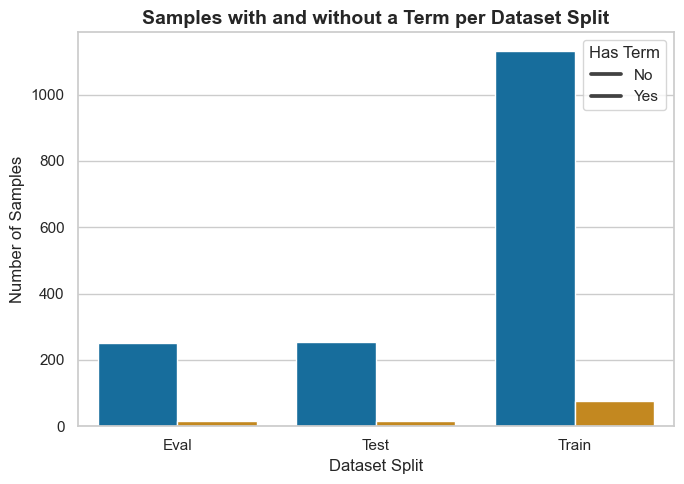

In [15]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

train_data["split"] = "Train"
eval_data["split"] = "Eval"
test_data["split"] = "Test"
data_all = pd.concat([train_data, eval_data, test_data], ignore_index=True)

# Determine if each row has a non-null term
data_all["has_term"] = data_all["term"].notna()

summary = (
    data_all.groupby(["split", "has_term"])
    .size()
    .reset_index(name="count")
)

summary_pivot = summary.pivot(index="split", columns="has_term", values="count").fillna(0)
summary_pivot.columns = ["No Term", "Has Term"]
summary_pivot["Total"] = summary_pivot.sum(axis=1)
summary_pivot = summary_pivot.astype(int).reset_index()

sns.set_theme(style="whitegrid", palette="colorblind")
plt.figure(figsize=(7, 5))
sns.barplot(data=summary, x="split", y="count", hue="has_term")


plt.title("Samples with and without a Term per Dataset Split", fontsize=14, weight="bold")
plt.xlabel("Dataset Split", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.legend(title="Has Term", labels=["No", "Yes"])
plt.tight_layout()

os.makedirs("images", exist_ok=True)
plot_path = "images/samples_with_and_without_term_v1.0.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

print(f"Figure saved to: {plot_path}")

plt.show()

In [16]:
# generate the LaTex
latex_table = summary_pivot.to_latex(
    index=False,
    caption="Number of samples with and without a term per dataset split.",
    label="tab:term-presence",
    column_format="lccc",
    bold_rows=True,
    escape=False
)

print(latex_table)

\begin{table}
\caption{Number of samples with and without a term per dataset split.}
\label{tab:term-presence}
\begin{tabular}{lccc}
\toprule
split & No Term & Has Term & Total \\
\midrule
Eval & 252 & 17 & 269 \\
Test & 254 & 17 & 271 \\
Train & 1131 & 76 & 1207 \\
\bottomrule
\end{tabular}
\end{table}



In [17]:
# \begin{table}
# \caption{Number of samples with and without a term per dataset split.}
# \label{tab:term-presence}
# \begin{tabular}{lccc}
# \toprule
# split & No Term & Has Term & Total \\
# \midrule
# Eval & 252 & 17 & 269 \\
# Test & 254 & 17 & 271 \\
# Train & 1131 & 76 & 1207 \\
# \bottomrule
# \end{tabular}
# \end{table}

#### **Preparing the dataset and dataloader**

Now that our data is preprocessed, we can turn it into PyTorch tensors such that we can provide it to the model. Let's start by defining some key variables that will be used later on in the training/evaluation process:

In [18]:
import random
import numpy as np
import torch

SEED = 2026

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make CUDA deterministic (slightly slower)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [19]:
MAX_LEN = 128 # might be a bit small
TRAIN_BATCH_SIZE = 32 # 4
VALID_BATCH_SIZE = 32 # 2
EPOCHS = 3 # 1
LEARNING_RATE = 3e-5 # 1e-05 -> For small datasets, you might even try 2e-5 or 3e-5.
MAX_GRAD_NORM = 2

BASE_MODEL = "bert-base-multilingual-uncased" # 'xlm-roberta-base' # "xlm-roberta-base" #"daviddallakyan2005/armenian-ner" # 'bert-base-multilingual-uncased'
# hye
from transformers import AutoTokenizer
# tokenizer = BertTokenizerFast.from_pretrained(BASE_MODEL)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

A tricky part of NER with BERT is that BERT relies on **wordpiece tokenization**, rather than word tokenization. This means that we should also define the labels at the wordpiece-level, rather than the word-level!

For example, if you have word like "Washington" which is labeled as "b-gpe", but it gets tokenized to "Wash", "##ing", "##ton", then one approach could be to handle this by only train the model on the tag labels for the first word piece token of a word (i.e. only label "Wash" with "b-gpe"). This is what was done in the original BERT paper, see Github discussion [here](https://github.com/huggingface/transformers/issues/64#issuecomment-443703063).

Note that this is a **design decision**. You could also decide to propagate the original label of the word to all of its word pieces and let the model train on this. In that case, the model should be able to produce the correct labels for each individual wordpiece. This was done in [this NER tutorial with BERT](https://github.com/chambliss/Multilingual_NER/blob/master/python/utils/main_utils.py#L118). Another design decision could be to give the first wordpiece of each word the original word label, and then use the label “X” for all subsequent subwords of that word. All of them seem to lead to good performance.

Below, we define a regular PyTorch [dataset class](https://pytorch.org/docs/stable/data.html) (which transforms examples of a dataframe to PyTorch tensors). Here, each sentence gets tokenized, the special tokens that BERT expects are added, the tokens are padded or truncated based on the max length of the model, the attention mask is created and the labels are created based on the dictionary which we defined above. Word pieces that should be ignored have a label of -100 (which is the default `ignore_index` of PyTorch's [CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)).

For more information about BERT's inputs, see [here](https://huggingface.co/transformers/glossary.html).








In [20]:
class dataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __getitem__(self, index):
        sentence = self.data.sentence[index].strip().split()
        word_labels = self.data.word_labels[index].split(",")

        encoding = self.tokenizer(
            sentence,
            is_split_into_words=True,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        # Create aligned labels
        labels = [labels_to_ids[label] for label in word_labels]
        word_ids = encoding.word_ids(batch_index=0)

        # Initialize with -100 - but for hye and other models roberta -> this is some other code
        encoded_labels = []
        previous_word_idx = None
        for word_idx in word_ids:
            if word_idx is None:
                encoded_labels.append(-100)
            elif word_idx != previous_word_idx:
                encoded_labels.append(labels[word_idx])
            else:
                encoded_labels.append(-100)
            previous_word_idx = word_idx

        # Convert everything to tensors
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(encoded_labels, dtype=torch.long)

        return item

    def __len__(self):
        return len(self.data)

Now, based on the class we defined above, we can create 2 datasets, one for training and one for testing. Let's use a 80/20 split:

In [21]:
training_set = dataset(train_data, tokenizer, MAX_LEN)


In [22]:
training_set[0]

{'input_ids': tensor([  101,   376, 11392, 18302, 15150,   381, 11297, 19360, 21114, 34828,
           390, 79708, 12944, 19054, 22711,   404, 27516, 27363, 18521, 27042,
         11392,   386, 19599, 63529, 14445,   380,   404, 90251, 17049,   374,
         14836, 63710, 13445, 12944, 19054, 83466, 62204, 21740, 48283, 13429,
           402, 14836, 27977, 59398,   403, 27542, 13429, 11297,   389, 42872,
         11392, 62100, 59398,   384,   374, 37486, 19069,   395, 59398, 90119,
           402,   404, 14416,   402, 15538, 20721, 61758, 13445, 52148, 35740,
           403, 11392, 80253, 19054, 91479, 11089,   403, 14416, 12944, 19054,
         26159,   380,   389, 42872, 11392, 62100, 29055, 81611, 17105, 92239,
         19360, 79708, 77757, 92471, 16487,   381,   385, 77124, 26681, 29055,
         81611, 16487, 18910,   102,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [23]:

testing_set = dataset(test_data, tokenizer, MAX_LEN)
validation_set = dataset(eval_data, tokenizer, MAX_LEN)

In [24]:
train_data.iloc[0]

Unnamed: 0                                                 50016
sentence       գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...
term                                                   վիմագրերը
page_number                                                  NaN
file_name                                          Divabn_Prak10
word                                                        գիմք
tag                                                            O
word_labels    O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN...
split                                                      Train
Name: 0, dtype: object

Let's have a look at the first training example:

In [25]:
testing_set[0]

{'input_ids': tensor([  101,   403, 21179, 13445, 31549, 15203,   382, 14836, 90971, 46834,
         27516, 21179, 13445, 31549, 15203,   386, 12944, 26487, 15150, 19998,
           380, 73667, 19054, 11297, 18119, 26159,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

Let's verify that the input ids and corresponding targets are correct:

In [26]:
train_data.head()

,Unnamed: 0,sentence,term,page_number,file_name,word,tag,word_labels,split
0,50016,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,NaN,Divabn_Prak10,գիմք,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN...",Train
1,50017,նախորդ հրատարակիչը վիմագրի ծանոթագրության մեջ ...,Վիմագիր,NaN,Divabn_Prak10,նախորդ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,...",Train
2,50018,ոմն առյուծի հայր սխիթար ճոն հիշատակված է նաև ա...,վիմագրերից,NaN,Divabn_Prak10,ոմն,O,"O,O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O...",Train
3,50019,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները,NaN,Divabn_Prak10,պրակն,O,"O,O,O,O,O,B-INSC,I-INSC",Train
4,50020,արևելյան նիրակի ներկայիս հ շիրակի մարզ վիմագիր...,վիմագիր,NaN,Divabn_Prak10,արևելյան,O,"O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O,O...",Train


In [27]:
for token, label in zip(tokenizer.convert_ids_to_tokens(training_set[9]["input_ids"]), training_set[9]["labels"]):
  print('{0:10}  {1}'.format(token, label))

[CLS]       -100
ծ           0
##ան        -100
##ո         -100
##թ         -100
վ           0
##ի         -100
##մա        -100
##գի        -100
##ր         -100
##ն         -100
ա           0
##մ         -100
##փ         -100
##ո         -100
##փ         -100
##ում       -100
է           0
##ե         -100
##կե        -100
##ղ         -100
##եց        -100
##ու        -100
շ           0
##ին        -100
##ար        -100
##արության  -100
մ           0
##անր       -100
##ամ        -100
##աս        -100
##ները      -100
հ           0
##ամ        -100
##ած        -100
##այն       -100
որոնց       0
ս           0
##կ         -100
##զ         -100
##բ         -100
##նա        -100
##պես       -100
ս           0
ա           0
##ստ        -100
##ված       -100
##ած        -100
##ին        -100
ապա         0
##ս         -100
ն           0
##շան       -100
անվան       0
##ա         -100
##փ         -100
##ո         -100
##խ         -100
##ված       -100
եկեղեցու    0
կա          0
##ռ        

-100 = ignore index -> loss is not computed for these positions (CrossEntropyLoss skips them).

Now, let's define the corresponding PyTorch dataloaders:

In [28]:
train_params = {'batch_size': TRAIN_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

test_params = {'batch_size': VALID_BATCH_SIZE,
                'shuffle': False,
                'num_workers': 0
                }

valid_params = {'batch_size': VALID_BATCH_SIZE,
                'shuffle': False,
                'num_workers': 0
                }

training_loader = DataLoader(training_set, **train_params)
testing_loader = DataLoader(testing_set, **test_params)
validation_loader = DataLoader(validation_set, **test_params)

#### **Defining the model**

Here we define the model, BertForTokenClassification, and load it with the pretrained weights of "bert-base-uncased". The only thing we need to additionally specify is the number of labels (as this will determine the architecture of the classification head).

Note that only the base layers are initialized with the pretrained weights. The token classification head of top has just randomly initialized weights, which we will train, together with the pretrained weights, using our labelled dataset. This is also printed as a warning when you run the code cell below.

Then, we move the model to the GPU.

In [29]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(BASE_MODEL, num_labels=len(labels_to_ids))
model.to(device)

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-1

#### **Training the model**

Before training the model, let's perform a sanity check, which I learned thanks to Andrej Karpathy's wonderful [cs231n course](http://cs231n.stanford.edu/) at Stanford (see also his [blog post about debugging neural networks](http://karpathy.github.io/2019/04/25/recipe/)). The initial loss of your model should be close to -ln(1/number of classes) = -ln(1/17) = 2.83.

Why? Because we are using cross entropy loss. The cross entropy loss is defined as -ln(probability score of the model for the correct class). In the beginning, the weights are random, so the probability distribution for all of the classes for a given token will be uniform, meaning that the probability for the correct class will be near 1/17. The loss for a given token will thus be -ln(1/17). As PyTorch's [CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) (which is used by `BertForTokenClassification`) uses *mean reduction* by default, it will compute the mean loss for each of the tokens in the sequence for which a label is provided.

Let's verify this:



In [30]:
# inputs = training_set[2]
# input_ids = inputs["input_ids"].unsqueeze(0)
# attention_mask = inputs["attention_mask"].unsqueeze(0)
# labels = inputs["labels"].unsqueeze(0)

# input_ids = input_ids.to(device)
# attention_mask = attention_mask.to(device)
# labels = labels.to(device)

# outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
# initial_loss = outputs[0]
# initial_loss

This looks good. Let's also verify that the logits of the neural network have a shape of (batch_size, sequence_length, num_labels):

In [31]:
# tr_logits = outputs[1]
# tr_logits.shape

In [32]:
import torch
from tqdm import tqdm

def predict(model, dataloader, device, ids_to_labels):
    """
    Generate predictions and ground truth labels for a token classification model.

    Args:
        model: Trained HuggingFace model (e.g., BertForTokenClassification)
        dataloader: DataLoader providing batches with 'input_ids', 'attention_mask', and 'labels'
        device: torch.device('cuda' or 'cpu')
        ids_to_labels: dict mapping label IDs to label strings

    Returns:
        labels_list: List[List[str]] — true labels per sentence (excluding padding)
        predictions_list: List[List[str]] — predicted labels per sentence (excluding padding)
    """
    model.eval()
    labels_list = []
    predictions_list = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Predicting", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            for i in range(labels.size(0)):
                sentence_labels = labels[i]               # (seq_len,)
                sentence_logits = logits[i]               # (seq_len, num_labels)
                sentence_preds = torch.argmax(sentence_logits, dim=-1)

                # Filter out ignored tokens (-100)
                active_mask = sentence_labels != -100
                filtered_labels = sentence_labels[active_mask]
                filtered_preds = sentence_preds[active_mask]

                labels_list.append([
                    ids_to_labels[id.item()] for id in filtered_labels
                ])
                predictions_list.append([
                    ids_to_labels[id.item()] for id in filtered_preds
                ])

    return labels_list, predictions_list

Next, we define the optimizer. Here, we are just going to use Adam with a default learning rate. One can also decide to use more advanced ones such as AdamW (Adam with weight decay fix), which is [included](https://huggingface.co/transformers/main_classes/optimizer_schedules.html) in the Transformers repository, and a learning rate scheduler, but we are not going to do that here.

In [33]:
optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)
# optimizer = torch.optim.AdamW(params=model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

Now let's define a regular PyTorch training function. It is partly based on [a really good repository about multilingual NER](https://github.com/chambliss/Multilingual_NER/blob/master/python/utils/main_utils.py#L344).

In [34]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import torch
from seqeval.metrics import classification_report, f1_score
import copy

def train_one_epoch(epoch, model, training_loader, validation_loader, optimizer, device, ids_to_labels, eval_every=100):
    tr_loss, tr_accuracy = 0, 0
    nb_tr_steps = 0

    train_step_losses = []   # training loss every 100 steps
    eval_step_losses = []    # validation loss every 100 steps

    best_f1 = 0.0
    best_model_state = None
    best_report = None

    model.train()
    progress_bar = tqdm(training_loader, desc=f"Epoch {epoch} [Training]", leave=False)

    for idx, batch in enumerate(progress_bar):
        ids = batch['input_ids'].to(device, dtype=torch.long)
        mask = batch['attention_mask'].to(device, dtype=torch.long)
        labels = batch['labels'].to(device, dtype=torch.long)

        outputs = model(input_ids=ids, attention_mask=mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        tr_loss += loss.item()
        nb_tr_steps += 1

        # Accuracy
        flattened_targets = labels.view(-1)
        active_logits = logits.view(-1, model.num_labels)
        flattened_predictions = torch.argmax(active_logits, axis=1)
        active_mask = flattened_targets != -100

        labels_filtered = torch.masked_select(flattened_targets, active_mask)
        preds_filtered = torch.masked_select(flattened_predictions, active_mask)

        tmp_tr_accuracy = accuracy_score(
            labels_filtered.cpu().numpy(),
            preds_filtered.cpu().numpy()
        )
        tr_accuracy += tmp_tr_accuracy

        # Gradient clipping + backward
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Record train loss every eval_every steps
        if idx % eval_every == 0 and idx > 0:
            avg_loss = tr_loss / nb_tr_steps
            train_step_losses.append(avg_loss)

            # Run quick evaluation every eval_every steps
            model.eval()
            eval_loss, eval_steps = 0, 0
            with torch.no_grad():
                for v_idx, v_batch in enumerate(validation_loader):
                    # if v_idx >= 5:  # limit evaluation to 5 batches to save time
                    #     break
                    v_ids = v_batch['input_ids'].to(device, dtype=torch.long)
                    v_mask = v_batch['attention_mask'].to(device, dtype=torch.long)
                    v_labels = v_batch['labels'].to(device, dtype=torch.long)

                    v_outputs = model(input_ids=v_ids, attention_mask=v_mask, labels=v_labels)
                    eval_loss += v_outputs.loss.item()
                    eval_steps += 1

                # Predict on validation data
                labels, predictions = predict(model, validation_loader, device, ids_to_labels)
                report = classification_report(labels, predictions, digits=4, output_dict=True)
                current_f1 = report["macro avg"]["f1-score"]

                print(f"\n[Step {idx}] F1 (macro): {current_f1:.4f}")
                eval_step_losses.append(eval_loss / eval_steps)

                # Save best model
                if current_f1 > best_f1:
                    best_f1 = current_f1
                    best_model_state = copy.deepcopy(model.state_dict())
                    best_report = report
                    print(f"  ✅ New best model (F1={best_f1:.4f}) saved.")

            model.train()

        # Update tqdm
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{tmp_tr_accuracy:.4f}'
        })

    epoch_loss = tr_loss / nb_tr_steps
    epoch_acc = tr_accuracy / nb_tr_steps

    print(f"\nEpoch {epoch} Summary:")
    print(f"  Training loss: {epoch_loss:.4f}")
    print(f"  Training accuracy: {epoch_acc:.4f}")
    if best_f1 > 0:
        print(f"  Best validation F1: {best_f1:.4f}")

    return {
        "epoch_loss": epoch_loss,
        "epoch_acc": epoch_acc,
        "train_step_losses": train_step_losses,
        "eval_step_losses": eval_step_losses,
        "best_f1": best_f1,
        "best_model_state": best_model_state,
        "best_report": best_report
    }

In [35]:
EPOCHS = 10

And let's train the model!

In [36]:
all_train_losses = []
all_eval_losses = []

best_f1_overall = 0.0
best_model_state_overall = None

for epoch in range(1, EPOCHS + 1):
    results = train_one_epoch(
        epoch,
        model,
        training_loader,
        validation_loader,
        optimizer,
        device,
        ids_to_labels,
        eval_every=10
    )

    # Extend training/evaluation losses
    all_train_losses.extend(results["train_step_losses"])
    all_eval_losses.extend(results["eval_step_losses"])

    # Display epoch summary
    print(f"\nEpoch {epoch} finished:")
    print(f"  Train loss: {results['epoch_loss']:.4f}")
    print(f"  Train acc:  {results['epoch_acc']:.4f}")
    print(f"  Best F1 in epoch: {results['best_f1']:.4f}")

    # Track overall best model
    if results["best_f1"] > best_f1_overall:
        best_f1_overall = results["best_f1"]
        best_model_state_overall = results["best_model_state"]
        print(f"  ✅ New overall best model (F1={best_f1_overall:.4f})")

# ✅ Load the best model after all epochs
if best_model_state_overall is not None:
    model.load_state_dict(best_model_state_overall)
    print(f"\n✅ Loaded best model (overall F1={best_f1_overall:.4f})")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Predicting: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:15<00:00,  1.21s/it]
                                                                                                                                                                                                                                                                                     /opt/anaconda3/envs/p11/lib/python3.11/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-sc


[Step 10] F1 (macro): 0.0000


Predicting: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:12<00:00,  1.16s/it]
                                                                                                                                                                                                                                                                                     /opt/anaconda3/envs/p11/lib/python3.11/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
Epoch 1 [Training]:  55%|███████████████████████████████████████████████████████████████████████████████████████████████████████████▊          


[Step 20] F1 (macro): 0.0000


Predicting: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:13<00:00,  1.42s/it]
                                                                                                                                                                                                                                                                                     /opt/anaconda3/envs/p11/lib/python3.11/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
Epoch 1 [Training]:  82%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

...

Epoch 10 [Training]:  55%|███████████████████████████████████████████████████████████████████████████████████████████████████████████▏                                                                                      | 21/38 [05:15<07:57, 28.08s/it, loss=0.0019, acc=1.0000]

  ✅ New best model (F1=0.9375) saved.


Epoch 10 [Training]:  82%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                   | 31/38 [08:33<03:09, 27.07s/it, loss=0.0027, acc=0.9975]


[Step 30] F1 (macro): 0.7895



Epoch 10 Summary:
  Training loss: 0.0044
  Training accuracy: 0.9981
  Best validation F1: 0.9375

Epoch 10 finished:
  Train loss: 0.0044
  Train acc:  0.9981
  Best F1 in epoch: 0.9375
  ✅ New overall best model (F1=0.9375)

✅ Loaded best model (overall F1=0.9375)


In [37]:
all_eval_losses

[0.02821243944991794,
 0.026626539313130908,
 0.026360079283929534,
 0.02035304257232282,
 0.01104711177241471,
 0.012258770940307941,
 0.01472271164594632,
 0.0110935623330685,
 0.011498566597260328,
 0.008159332637054225,
 0.00780803970216463,
 0.012445943433299867,
 0.009958984909139367,
 0.007157704970773516,
 0.006494075145585359,
 0.006947947069420479,
 0.008219265003895594,
 0.007908260634899812,
 0.008572456242594248,
 0.007498176521039568,
 0.007500697179542233,
 0.007154064042778272,
 0.0070543654081929065,
 0.006852501198106135,
 0.008135822658207163,
 0.007453232564633557,
 0.00753763701181419,
 0.006734260010287269,
 0.0061412390148487045,
 0.008177347841814885]

Save the model

In [62]:
# ✅ Load the best model after all epochs
if best_model_state_overall is not None:
    model.load_state_dict(best_model_state_overall)
    print(f"\n✅ Loaded best model (overall F1={best_f1_overall:.4f})")


✅ Loaded best model (overall F1=0.9375)


Let's see if there's any [underfitting/overfitting](https://www.geeksforgeeks.org/machine-learning/underfitting-and-overfitting-in-machine-learning/).

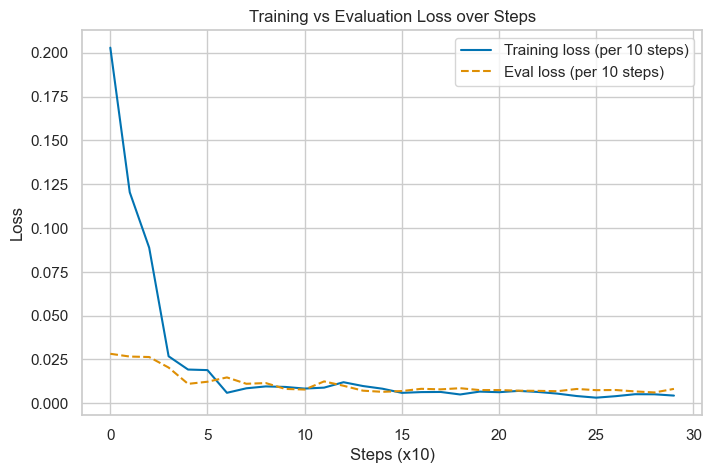

Saved figure to: images/training_train_eval_loss_run2.png


In [64]:
import os
import matplotlib.pyplot as plt

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(all_train_losses, label='Training loss (per 10 steps)')
plt.plot(all_eval_losses, label='Eval loss (per 10 steps)', linestyle='--')
plt.xlabel("Steps (x10)")
plt.ylabel("Loss")
plt.title("Training vs Evaluation Loss over Steps")
plt.legend()

save_path = "images/training_train_eval_loss_run2.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"Saved figure to: {save_path}")

#### **Evaluating the model**

Now that we've trained our model, we can evaluate its performance on the held-out test set (which is 20% of the data). Note that here, no gradient updates are performed, the model just outputs its logits.

In [ ]:
from seqeval.metrics import classification_report

labels, predictions = predict(model, testing_loader, device, ids_to_labels)

print(classification_report(labels, predictions, digits=4))



Predicting:  78%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                   | 7/9 [00:11<00:03,  1.51s/it]

However, the accuracy metric is misleading, as a lot of labels are "outside" (O), even after omitting predictions on the [PAD] tokens. What is important is looking at the precision, recall and f1-score of the individual tags. For this, we use the seqeval Python library:

Performance already seems quite good, but note that we've only trained for 1 epoch. An optimal approach would be to perform evaluation on a validation set while training to improve generalization.

In [41]:
valid_labels, valid_predictions = predict(model, validation_loader, device, ids_to_labels)
print(classification_report(valid_labels, valid_predictions, digits=4))

              precision    recall  f1-score   support

        INSC     1.0000    0.8824    0.9375        17

   micro avg     1.0000    0.8824    0.9375        17
   macro avg     1.0000    0.8824    0.9375        17
weighted avg     1.0000    0.8824    0.9375        17



In [42]:
import pandas as pd

def predictions_to_dataframe(test_data, predictions, entity_tags=("B-INSC", "I-INSC")):
    """
    Convert token-level predictions into a dataframe with extracted entity spans.

    Args:
        test_data (pd.DataFrame): DataFrame with a 'sentence' column (space-separated tokens).
        predictions (List[List[str]]): List of predicted tag sequences for each sentence.
        entity_tags (Tuple[str]): Tags to include when extracting entity tokens (default: B-INSC, I-INSC).

    Returns:
        pd.DataFrame: Columns ['sentence', 'predicted_inscriptions']
    """
    sentences, predicted_entities = [], []

    for idx, preds in enumerate(predictions):
        # Get sentence tokens
        tokens = test_data.sentence.iloc[idx].strip().split()
        min_len = min(len(tokens), len(preds))

        # Align to avoid mismatch
        tokens = tokens[:min_len]
        preds = preds[:min_len]

        # Extract tokens predicted as entity
        entity_tokens = [tok for tok, tag in zip(tokens, preds) if tag in entity_tags]

        sentences.append(" ".join(tokens))
        predicted_entities.append(" ".join(entity_tokens))

    df_pred = pd.DataFrame({
        "sentence": sentences,
        "predicted_inscriptions": predicted_entities
    })

    return df_pred

In [43]:
df_predictions = predictions_to_dataframe(test_data, predictions)
df_predictions.head()

,sentence,predicted_inscriptions
0,վլանէս թրտաշվլանէս խաչքար է կանգնեցրել,
1,սմբատ նահնշահ ովհաննես սմբատ հայոց թագավոր թթ ...,
2,սարգիս ձորավորաց եկեղեցու վանահայր խաչքարէ կան...,
3,մարմաշեն հյ գերեզմանոց տապանագիր,տապանագիր
4,սարմաշեն գլխավոր տաճար հվ պատ արտ ոդ նվիրատվակ...,տապանագիր


In [44]:
# Extract all unique inscription terms from the training data
train_inscriptions = set()

for sentence, labels in zip(train_data.sentence, train_data.word_labels):
    tokens = sentence.strip().split()
    tags = labels.split(",")
    for token, tag in zip(tokens, tags):
        if tag in ("B-INSC", "I-INSC"):
            train_inscriptions.add(token)

print(f"{len(train_inscriptions)} unique inscription terms in training data")

24 unique inscription terms in training data


In [45]:
# Flatten all predicted inscriptions from your dataframe
predicted_inscriptions = set()

for insc_str in df_predictions["predicted_inscriptions"]:
    for token in insc_str.split():
        if token.strip():
            predicted_inscriptions.add(token)

print(f"{len(predicted_inscriptions)} unique inscription terms predicted")

4 unique inscription terms predicted


In [46]:
new_predicted_inscriptions = predicted_inscriptions - train_inscriptions

print(f"{len(new_predicted_inscriptions)} new inscription terms (not seen during training)")
print(new_predicted_inscriptions) # false positives

2 new inscription terms (not seen during training)
{'տապանագրում', 'տապանագիր'}


```
'donor', 'to do'
```

## Augmented Dataset

We need to *re-load* the model:

In [47]:
# model = BertForTokenClassification.from_pretrained(BASE_MODEL, num_labels=len(labels_to_ids))
# model.to(device)

In [48]:
# train_data_aug = pd.read_csv('dataset_formation/data/train_ner_aug_doctored.csv')
# # eval_data_aug= pd.read_csv('dataset_formation/data/eval_ner_aug_doctored.csv')

# eval_data_aug = pd.read_csv('dataset_formation/data/eval_ner_doctored.csv') # eval simulates a real test
# test_data_aug = pd.read_csv('dataset_formation/data/test_ner_doctored.csv')


In [49]:

# training_set_aug = dataset(train_data_aug, tokenizer, MAX_LEN)
# validation_set_aug = dataset(eval_data_aug, tokenizer, MAX_LEN)

In [50]:
# training_loader_aug = DataLoader(training_set_aug, **train_params)
# # validation_loader_aug = DataLoader(validation_set_aug, **test_params)

In [51]:
# for epoch in range(EPOCHS):
#     print(f"Training epoch: {epoch + 1}")
#     train(epoch,training_loader=training_loader_aug)

In [52]:
# all_train_losses = []
# all_eval_losses = []

# for epoch in range(1, EPOCHS + 1):
#     train_loss, train_acc, step_train_losses, step_eval_losses = train_one_epoch(
#         epoch, model, training_loader_aug, validation_loader, optimizer, device, ids_to_labels, eval_every=100
#     )
#     all_train_losses.extend(step_train_losses)
#     all_eval_losses.extend(step_eval_losses)

Save the model..

In [53]:
# code for saving the model

In [54]:
# plt.figure(figsize=(8,5))
# plt.plot(all_train_losses, label='Training loss (per 100 steps)')
# plt.plot(all_eval_losses, label='Eval loss (per 100 steps)', linestyle='--')
# plt.xlabel("Steps (x100)")
# plt.ylabel("Loss")
# plt.title("Training vs Evaluation Loss over Steps")
# plt.legend()
# plt.show()

In [55]:
# test_aug_labels, test_aug_predictions = predict(model, testing_loader, device, ids_to_labels)
# print(classification_report(test_aug_labels, test_aug_predictions, digits=4))

In [56]:
# test_aug_predictions[:5]

In [57]:
# test_aug_labels[:5]

In [58]:
# valid_labels, valid_predictions = predict(model, validation_loader, device, ids_to_labels)
# print(classification_report(valid_labels, valid_predictions, digits=4))

In [59]:
# df_aug_predictions = predictions_to_dataframe(test_data, test_aug_predictions)
# df_aug_predictions.head()

In [60]:
# df_predictions.predicted_inscriptions.head()


In [61]:
# labels, predictions = valid_rough(model, testing_loader,device,ids_to_labels)
# print(classification_report(labels, predictions,digits=4))